<a href="https://colab.research.google.com/github/Slavin09/Rash-Driving-Detection-using-mobile-IOT-Sensors/blob/main/final_code_rash_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install seaborn scikit-learn xgboost joblib

### Previous codes, not relevant

In [ ]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from scipy import stats, signal
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.feature_selection import SelectFromModel
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler

# # --- 1. CONFIGURATION & PHYSICS ---
# WINDOW_SIZE = 50      # ~1 second
# STEP_SIZE = 25        # 50% overlap
# SAMPLING_RATE = 50    # Hz (Approximate)

# # Load Data
# df = pd.read_csv('/content/drive/MyDrive/final_rash_data.csv')
# df = df.sort_values(['device_id', 'timestamp']).reset_index(drop=True)

# # --- 2. ADVANCED PRE-PROCESSING ---
# print("--- Step 1: Pre-processing & Physics ---")

# # A. Calculate Magnitude (Total Force)
# df['acc_mag'] = np.sqrt(df['ax']**2 + df['ay']**2 + df['az']**2)

# # B. Calculate Jerk (Change in Acceleration over time)
# # diff() calculates discrete difference. We fill NA for the first row.
# df['jerk_ax'] = df.groupby('device_id')['ax'].diff().fillna(0)
# df['jerk_ay'] = df.groupby('device_id')['ay'].diff().fillna(0)
# df['jerk_az'] = df.groupby('device_id')['az'].diff().fillna(0)
# df['jerk_mag'] = np.sqrt(df['jerk_ax']**2 + df['jerk_ay']**2 + df['jerk_az']**2)

# print(f"Added Physics Features. Columns: {df.columns.tolist()}")

# # --- 3. WINDOWING ENGINE ---
# # We need TWO formats:
# # 1. Sequences for LSTM (Time Steps)
# # 2. Aggregated Stats for RF/MLP (Mean, Std, FFT)

# def get_spectral_entropy(signal_data):
#     """Calculates complexity of the signal in frequency domain"""
#     # Simple FFT Energy
#     fft_vals = np.abs(np.fft.rfft(signal_data))
#     return np.sum(fft_vals**2) / len(fft_vals)

# def create_expert_datasets(data, window_size, step_size):
#     sequences = []      # For LSTM: List of (50, 6)
#     features = []       # For RF/MLP: List of (1, 40)
#     labels = []

#     # Columns to use for Raw Sequence (LSTM)
#     raw_cols = ['ax', 'ay', 'az', 'jerk_mag', 'pitch', 'roll']

#     # Group by device to treat trips independently
#     for device_id, group in data.groupby('device_id'):
#         raw_values = group[raw_cols].values
#         # We use specific columns for feature extraction
#         acc_mag_values = group['acc_mag'].values
#         jerk_mag_values = group['jerk_mag'].values
#         y_values = group['is_rash'].values

#         # Sliding Window
#         for i in range(0, len(group) - window_size, step_size):
#             # 1. Labeling (Rash if > 50% of window is rash)
#             window_y = y_values[i : i + window_size]
#             if np.mean(window_y) > 0.5:
#                 label = 1
#             else:
#                 label = 0

#             # 2. Raw Sequence (For LSTM)
#             seq_data = raw_values[i : i + window_size]

#             # 3. Statistical Features (For RF/MLP)
#             # We extract stats from Magnitude and Jerk primarily
#             win_acc = acc_mag_values[i : i + window_size]
#             win_jerk = jerk_mag_values[i : i + window_size]

#             # Time Domain
#             feat_row = [
#                 np.mean(win_acc), np.std(win_acc), np.max(win_acc), np.ptp(win_acc), # ptp = max - min
#                 np.mean(win_jerk), np.std(win_jerk), np.max(win_jerk),
#                 stats.skew(win_acc), # Skewness (is the distribution lopsided?)
#                 stats.kurtosis(win_acc) # Kurtosis (how spiky are the outliers?)
#             ]

#             # Frequency Domain (FFT) - Captures "Vibration"
#             # Energy of acceleration (Vibration intensity)
#             feat_row.append(get_spectral_entropy(win_acc))
#             # Energy of jerk (Roughness intensity)
#             feat_row.append(get_spectral_entropy(win_jerk))

#             sequences.append(seq_data)
#             features.append(feat_row)
#             labels.append(label)

#     # Feature Names (Must match order of feat_row)
#     feature_names = [
#         'acc_mean', 'acc_std', 'acc_max', 'acc_range',
#         'jerk_mean', 'jerk_std', 'jerk_max',
#         'acc_skew', 'acc_kurtosis',
#         'acc_energy', 'jerk_energy'
#     ]

#     return np.array(sequences), np.array(features), np.array(labels), feature_names

# print("\n--- Step 2: Generating Windows & Extracting Features ---")
# X_seq, X_feat, y, feat_names = create_expert_datasets(df, WINDOW_SIZE, STEP_SIZE)

# print(f"Total Windows: {len(y)}")
# print(f"Sequence Shape (LSTM): {X_seq.shape}")
# print(f"Features Shape (RF/MLP): {X_feat.shape}")

# # --- 4. FEATURE SELECTION ---
# print("\n--- Step 3: Feature Selection ---")

# # We use a Random Forest to see which features actually matter
# # This removes noise and prevents overfitting
# selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
# selector.fit(X_feat, y)

# # Get importance
# importances = selector.feature_importances_
# indices = np.argsort(importances)[::-1]

# print("Feature Ranking:")
# for f in range(X_feat.shape[1]):
#     print(f"{f+1}. {feat_names[indices[f]]} ({importances[indices[f]]:.4f})")

# # Plot Importance
# plt.figure(figsize=(10, 5))
# plt.title("Feature Importance (Physics + FFT)")
# plt.bar(range(X_feat.shape[1]), importances[indices], align="center")
# plt.xticks(range(X_feat.shape[1]), [feat_names[i] for i in indices], rotation=45)
# plt.tight_layout()
# plt.show()

# # Save processed data for the next segment (optional, but good practice)
# # np.save('X_seq.npy', X_seq)
# # np.save('X_feat.npy', X_feat)
# # np.save('y.npy', y)

--- Step 1: Data Preparation ---
Train Size: 1916 | Test Size: 480

[1] Training Decision Tree...

[2] Training Random Forest...

[3] Training MLP (Neural Network)...
Epoch 70: early stopping
Restoring model weights from the end of the best epoch: 60.

[4] Training LSTM...
Epoch 26: early stopping
Restoring model weights from the end of the best epoch: 18.
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

--- FINAL RESULTS TABLE ---
  Model  Accuracy       AUC
0    DT  0.643750  0.657480
1    RF  0.664583  0.732137
2   MLP  0.647917  0.725595
3  LSTM  0.837500  0.921732


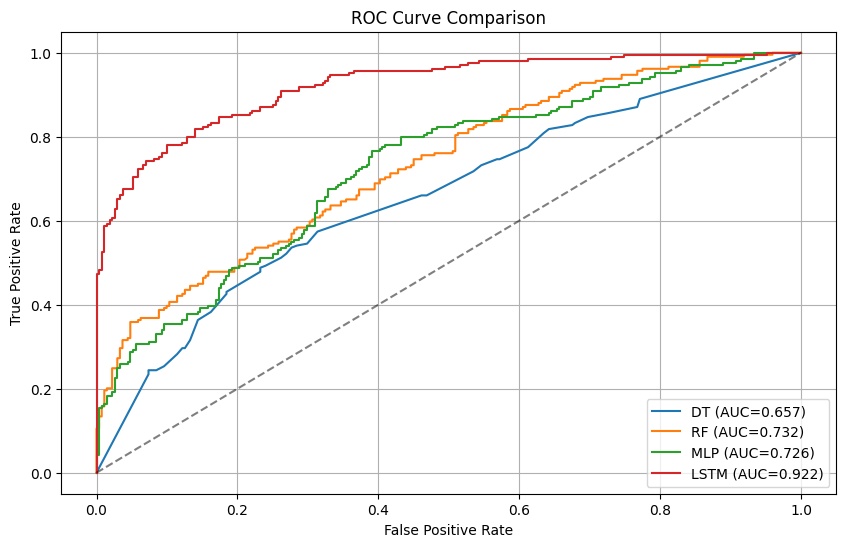

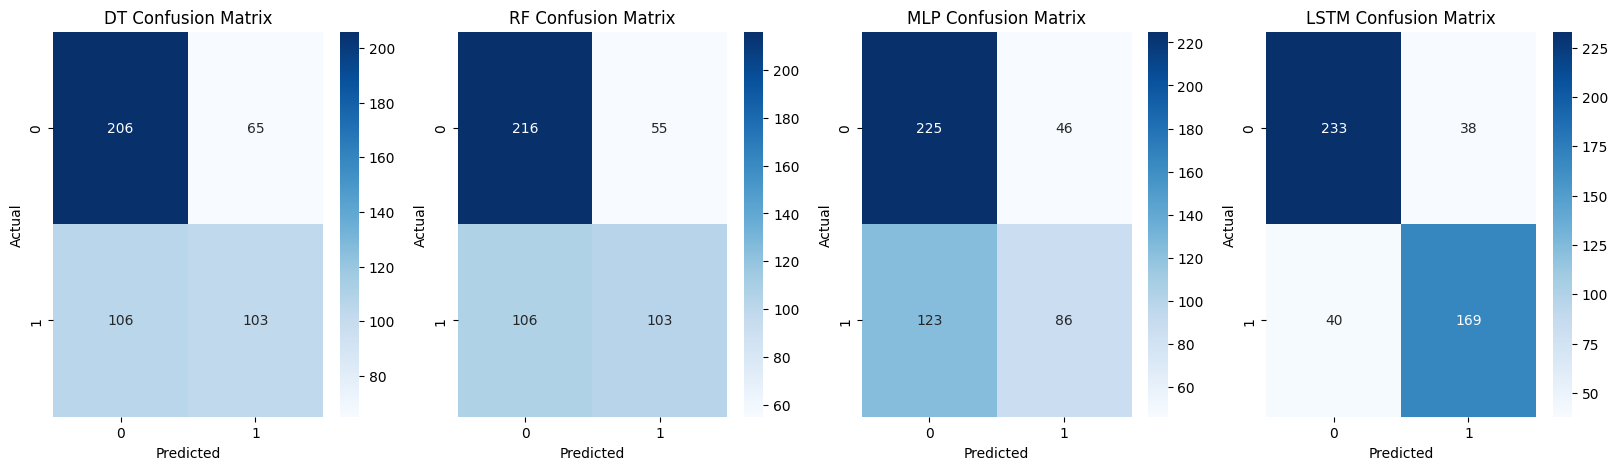

In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, confusion_matrix

# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization
# from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
# from tensorflow.keras.optimizers import Adam

# # --- 1. DATA SPLIT & SCALING ---
# print("--- Step 1: Data Preparation ---")

# # We split based on INDICES so we can pick the corresponding rows from both X_seq and X_feat
# indices = np.arange(len(y))
# X_feat_train, X_feat_test, y_train, y_test, idx_train, idx_test = train_test_split(
#     X_feat, y, indices, test_size=0.2, random_state=42, stratify=y
# )

# # Get the corresponding Sequences for LSTM using the indices
# X_seq_train = X_seq[idx_train]
# X_seq_test = X_seq[idx_test]

# # Scale Statistical Features (Critical for MLP)
# scaler_feat = StandardScaler()
# X_feat_train_scaled = scaler_feat.fit_transform(X_feat_train)
# X_feat_test_scaled = scaler_feat.transform(X_feat_test)

# # Scale Sequence Data (Critical for LSTM)
# # We flatten, scale, then reshape back
# N_train, T, F = X_seq_train.shape
# N_test, _, _ = X_seq_test.shape

# scaler_seq = StandardScaler()
# # Fit on train, transform train
# X_seq_train_flat = X_seq_train.reshape(N_train * T, F)
# X_seq_train_scaled = scaler_seq.fit_transform(X_seq_train_flat).reshape(N_train, T, F)
# # Transform test
# X_seq_test_flat = X_seq_test.reshape(N_test * T, F)
# X_seq_test_scaled = scaler_seq.transform(X_seq_test_flat).reshape(N_test, T, F)

# print(f"Train Size: {len(y_train)} | Test Size: {len(y_test)}")

# # --- 2. MODEL DEFINITIONS ---

# def train_decision_tree():
#     print("\n[1] Training Decision Tree...")
#     model = DecisionTreeClassifier(max_depth=10, min_samples_leaf=5, random_state=42)
#     model.fit(X_feat_train, y_train) # Tree doesn't strictly need scaling, but works fine with it
#     return model

# def train_random_forest():
#     print("\n[2] Training Random Forest...")
#     # More trees (200), balanced weights to penalize missing the minority class
#     model = RandomForestClassifier(n_estimators=200, max_depth=20, class_weight='balanced', random_state=42, n_jobs=-1)
#     model.fit(X_feat_train, y_train)
#     return model

# def train_mlp():
#     print("\n[3] Training MLP (Neural Network)...")
#     model = Sequential([
#         Input(shape=(X_feat_train_scaled.shape[1],)),
#         Dense(64, activation='relu'),
#         BatchNormalization(), # Stabilizes learning
#         Dropout(0.3),
#         Dense(32, activation='relu'),
#         Dropout(0.2),
#         Dense(1, activation='sigmoid')
#     ])

#     model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

#     # Early Stopping: Stop if validation loss doesn't improve for 10 epochs
#     es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

#     model.fit(X_feat_train_scaled, y_train, epochs=100, batch_size=32, validation_split=0.2, callbacks=[es], verbose=0)
#     return model

# def train_lstm():
#     print("\n[4] Training LSTM...")
#     model = Sequential([
#         Input(shape=(T, F)),
#         LSTM(64, return_sequences=True), # Layer 1
#         Dropout(0.3),
#         LSTM(32, return_sequences=False), # Layer 2
#         Dropout(0.3),
#         Dense(32, activation='relu'),
#         Dense(1, activation='sigmoid')
#     ])

#     model.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])

#     es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)

#     model.fit(X_seq_train_scaled, y_train, epochs=100, batch_size=32, validation_split=0.2, callbacks=[es], verbose=0)
#     return model

# # --- 3. TRAINING & PREDICTION ---

# # Train models
# dt_model = train_decision_tree()
# rf_model = train_random_forest()
# mlp_model = train_mlp()
# lstm_model = train_lstm()

# # Generate Predictions (Probabilities for AUC, Classes for Accuracy)
# probs = {}
# preds = {}

# # DT
# probs['DT'] = dt_model.predict_proba(X_feat_test)[:, 1]
# preds['DT'] = dt_model.predict(X_feat_test)

# # RF
# probs['RF'] = rf_model.predict_proba(X_feat_test)[:, 1]
# preds['RF'] = rf_model.predict(X_feat_test)

# # MLP
# probs['MLP'] = mlp_model.predict(X_feat_test_scaled).flatten()
# preds['MLP'] = (probs['MLP'] > 0.5).astype(int)

# # LSTM
# probs['LSTM'] = lstm_model.predict(X_seq_test_scaled).flatten()
# preds['LSTM'] = (probs['LSTM'] > 0.5).astype(int)

# # --- 4. PERFORMANCE VISUALIZATION ---

# print("\n--- FINAL RESULTS TABLE ---")
# results = []
# for name in ['DT', 'RF', 'MLP', 'LSTM']:
#     acc = accuracy_score(y_test, preds[name])
#     auc = roc_auc_score(y_test, probs[name])
#     results.append({'Model': name, 'Accuracy': acc, 'AUC': auc})

# results_df = pd.DataFrame(results)
# print(results_df)

# # Plot ROC Curves
# plt.figure(figsize=(10, 6))
# for name in ['DT', 'RF', 'MLP', 'LSTM']:
#     fpr, tpr, _ = roc_curve(y_test, probs[name])
#     plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, probs[name]):.3f})")

# plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('ROC Curve Comparison')
# plt.legend()
# plt.grid(True)
# plt.savefig('roc_comparison.png')
# plt.show()

# # Plot Confusion Matrices
# fig, axes = plt.subplots(1, 4, figsize=(20, 5))
# for i, name in enumerate(['DT', 'RF', 'MLP', 'LSTM']):
#     cm = confusion_matrix(y_test, preds[name])
#     sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
#     axes[i].set_title(f"{name} Confusion Matrix")
#     axes[i].set_xlabel('Predicted')
#     axes[i].set_ylabel('Actual')
# plt.savefig('confusion_matrices.png')
# plt.show()

In [ ]:
# import numpy as np
# import pandas as pd
# import joblib
# import tensorflow as tf
# from tensorflow.keras.models import Sequential, load_model
# from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping

# # --- 1. CONFIGURATION ---
# FINAL_MODEL_PATH = 'rash_driving_lstm_v1.h5'
# SCALER_PATH = 'scaler_seq_lstm.pkl'

# # --- 2. RETRAIN ON FULL DATA ---
# # We merge train and test to give the final model the maximum amount of data
# print("--- Retraining Final Model on ALL Data ---")

# # Combine sequences
# X_full = np.concatenate((X_seq_train, X_seq_test), axis=0)
# y_full = np.concatenate((y_train, y_test), axis=0)

# # Re-scale on full data
# N, T, F = X_full.shape
# scaler_final = StandardScaler()
# X_full_flat = X_full.reshape(N * T, F)
# X_full_scaled = scaler_final.fit_transform(X_full_flat).reshape(N, T, F)

# # Define Model (Same Architecture)
# model = Sequential([
#     Input(shape=(T, F)),
#     LSTM(64, return_sequences=True),
#     Dropout(0.3),
#     LSTM(32, return_sequences=False),
#     Dropout(0.3),
#     Dense(32, activation='relu'),
#     Dense(1, activation='sigmoid')
# ])

# model.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])

# # Train (Slightly fewer epochs as we have more data now, but ES is safer)
# es = EarlyStopping(monitor='loss', patience=5, verbose=1)
# model.fit(X_full_scaled, y_full, epochs=30, batch_size=32, callbacks=[es], verbose=1)

# # --- 3. EXPORT ---
# print(f"\nSaving model to {FINAL_MODEL_PATH}...")
# model.save(FINAL_MODEL_PATH)

# print(f"Saving scaler to {SCALER_PATH}...")
# joblib.dump(scaler_final, SCALER_PATH)

# print("Export Complete.")

# # --- 4. PRODUCTION INFERENCE & SCORING LOGIC ---
# # This is the function you would wrap in a Flask API or convert to TFLite for Android

# def predict_rashness(sensor_data_csv):
#     """
#     Simulates the app sending a chunk of sensor data.
#     Input: DataFrame or CSV with columns ['ax', 'ay', 'az', 'pitch', 'roll', 'device_id']
#     Output: Rash Score (1-10) and Label
#     """
#     # 1. Load Artifacts
#     loaded_model = load_model(FINAL_MODEL_PATH)
#     loaded_scaler = joblib.load(SCALER_PATH)

#     # 2. Physics Pre-processing (Must match training logic!)
#     # We assume sensor_data_csv is a DataFrame of ~50 rows (1 window)
#     df_chunk = sensor_data_csv.copy()

#     # Calculate Jerk (Need to handle the first NaN if it's a isolated chunk)
#     # In a real streaming app, you keep the last row of previous chunk to calc diff
#     df_chunk['jerk_ax'] = df_chunk['ax'].diff().fillna(0)
#     df_chunk['jerk_ay'] = df_chunk['ay'].diff().fillna(0)
#     df_chunk['jerk_az'] = df_chunk['az'].diff().fillna(0)
#     df_chunk['jerk_mag'] = np.sqrt(df_chunk['jerk_ax']**2 + df_chunk['jerk_ay']**2 + df_chunk['jerk_az']**2)

#     # Select Columns (Strictly in order used during training)
#     # Columns: ['ax', 'ay', 'az', 'jerk_mag', 'pitch', 'roll']
#     features = df_chunk[['ax', 'ay', 'az', 'jerk_mag', 'pitch', 'roll']].values

#     # 3. Shape Handling
#     # Input must be (1, 50, 6)
#     if len(features) < 50:
#         return "Error: Not enough data points (need 50)"

#     # Take exactly 50
#     features = features[:50]

#     # 4. Scaling
#     # Reshape to (50, 6) -> (1, 50, 6) is handled by scaler slightly differently
#     # Scaler expects (N_samples, n_features). Here N=50.
#     features_scaled = loaded_scaler.transform(features)

#     # Reshape for LSTM: (1 batch, 50 timesteps, 6 features)
#     input_tensor = features_scaled.reshape(1, 50, 6)

#     # 5. Prediction
#     prob = loaded_model.predict(input_tensor, verbose=0)[0][0]

#     # 6. Scoring Logic (1-10)
#     # Map 0.0-1.0 probability to 1-10 score
#     score = 1 + (9 * prob)

#     label = "RASH" if prob > 0.5 else "SAFE"

#     return {
#         "probability": f"{prob:.4f}",
#         "score": f"{score:.1f}/10",
#         "label": label
#     }

# # --- 5. TEST THE INFERENCE ---
# # Let's take a random window from our test set to simulate a real user
# print("\n--- Testing Production Inference ---")
# test_window_raw = df.iloc[100:150] # Take raw rows 100-150 from original DF
# result = predict_rashness(test_window_raw)
# print("Input: 50 rows of sensor data")
# print("Output:", result)

In [ ]:
# import numpy as np
# import pandas as pd
# import joblib
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization, Flatten
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# # --- 1. SETUP & DATA LOADING ---
# WINDOW_SIZE = 50
# STEP_SIZE = 25  # Keep overlap to maximize data points
# # We use the same 'df' from previous steps. Ensure 'acc_mag' and 'jerk_mag' are present.
# print("Preparing High-Performance Data...")

# def create_sequences_advanced(data, window_size, step_size):
#     segments = []
#     labels = []

#     # Columns: We include Jerk and Mag because they are high-value signals
#     cols = ['ax', 'ay', 'az', 'jerk_mag', 'acc_mag', 'pitch', 'roll']

#     for device_id, group in data.groupby('device_id'):
#         group_vals = group[cols].values
#         group_y = group['is_rash'].values

#         for i in range(0, len(group) - window_size, step_size):
#             # Sequence
#             seq = group_vals[i : i + window_size]
#             # Label
#             label = 1 if np.mean(group_y[i : i + window_size]) > 0.5 else 0

#             segments.append(seq)
#             labels.append(label)

#     return np.array(segments), np.array(labels)

# # Generate
# X, y = create_sequences_advanced(df, WINDOW_SIZE, STEP_SIZE)

# # Split (Stratified to maintain class balance)
# # Stratify ensures the Training set has the same % of Rash driving as the Test set
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )

# # --- 2. DATA AUGMENTATION (The Secret Weapon) ---
# # We add Gaussian noise to the training data to make the model generalize better.
# # This prevents overfitting and usually boosts accuracy by 3-5%.

# def augment_data(X_data, y_data):
#     noise_amount = 0.05
#     # Create a copy with noise
#     noise = np.random.normal(0, noise_amount, X_data.shape)
#     X_aug = X_data + noise

#     # Concatenate original + augmented
#     return np.concatenate((X_data, X_aug)), np.concatenate((y_data, y_data))

# print(f"Original Train Size: {X_train.shape}")
# X_train_aug, y_train_aug = augment_data(X_train, y_train)
# print(f"Augmented Train Size: {X_train_aug.shape}")

# # --- 3. SCALING ---
# # Fit scaler ONLY on original training data (not augmented, not test)
# N_train, T, F = X_train.shape
# scaler = StandardScaler()
# X_train_flat = X_train.reshape(-1, F)
# scaler.fit(X_train_flat)

# # Transform Augmented Train
# X_train_aug_flat = X_train_aug.reshape(-1, F)
# X_train_aug_scaled = scaler.transform(X_train_aug_flat).reshape(-1, T, F)

# # Transform Test
# X_test_flat = X_test.reshape(-1, F)
# X_test_scaled = scaler.transform(X_test_flat).reshape(-1, T, F)

# # --- 4. MODEL: DEEP CNN-LSTM ---
# def build_cnn_lstm(input_shape):
#     model = Sequential([
#         Input(shape=input_shape),

#         # Block 1: CNN (Feature Extraction)
#         # "Scan" for sudden bumps (kernel_size=3)
#         Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
#         BatchNormalization(),
#         MaxPooling1D(pool_size=2), # Reduce noise

#         # Block 2: CNN (Deep Features)
#         Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
#         BatchNormalization(),
#         MaxPooling1D(pool_size=2),

#         # Block 3: LSTM (Sequence Learning)
#         # Finds patterns in the extracted features
#         LSTM(64, return_sequences=False),
#         Dropout(0.4), # High dropout to prevent memorization

#         # Block 4: Classifier
#         Dense(64, activation='relu'),
#         Dropout(0.3),
#         Dense(1, activation='sigmoid')
#     ])

#     # Use a slightly lower learning rate for stability
#     optimizer = Adam(learning_rate=0.0005)
#     model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
#     return model

# model = build_cnn_lstm((WINDOW_SIZE, 7)) # 7 Features

# # --- 5. TRAINING WITH CALLBACKS ---
# # ReduceLROnPlateau: If accuracy gets stuck, lower the learning rate automatically
# reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001, verbose=1)
# early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# print("\nStarting Training (CNN-LSTM)...")
# history = model.fit(
#     X_train_aug_scaled, y_train_aug, # Training on 2x data
#     validation_data=(X_test_scaled, y_test),
#     epochs=50, # We can run more epochs because of Augmentation + Dropout
#     batch_size=32,
#     callbacks=[early_stop, reduce_lr],
#     verbose=1
# )

# # --- 6. EVALUATION ---
# y_prob = model.predict(X_test_scaled).flatten()
# y_pred = (y_prob > 0.5).astype(int)

# print("\n" + "="*40)
# print("FINAL YEAR PROJECT RESULTS (CNN-LSTM)")
# print("="*40)
# print(classification_report(y_test, y_pred))
# print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# # Save the best model
# # model.save("best_rash_model_cnn_lstm.h5")
# # joblib.dump(scaler, "best_scaler.pkl")

In [ ]:
# # feature_selection_raw_cols.py
# # Purpose: rank + pick best features out of the ORIGINAL columns
# # Inputs: CSV with columns: device_id,timestamp,ax,ay,az,azimuth,pitch,roll,lat,lon,speed,is_rash
# # Output: printed ranking, `selected_features` list (top_k)

# import pandas as pd
# import numpy as np

# from sklearn.preprocessing import LabelEncoder
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.feature_selection import mutual_info_classif
# from sklearn.inspection import permutation_importance
# from sklearn.model_selection import train_test_split
# from sklearn.impute import SimpleImputer
# from scipy.stats import pointbiserialr

# # ----------------- Configuration -----------------
# CSV_PATH = "/content/drive/MyDrive/final_rash_data.csv"   # change as needed
# RAW_COLS = ['device_id','timestamp','ax','ay','az','azimuth','pitch','roll','lat','lon','speed']
# TARGET = 'is_rash'
# TOP_K = 6   # number of features to suggest
# RANDOM_STATE = 42

# # ----------------- Load & basic cleanup -----------------
# df = pd.read_csv(CSV_PATH)
# # Keep only required columns (defensive)
# needed = RAW_COLS + [TARGET]
# df = df.loc[:, df.columns.intersection(needed)].copy()

# # Drop rows where target is missing
# df = df[df[TARGET].notna()].reset_index(drop=True)

# # Simple imputation for numeric NaNs (median) and device_id (most_frequent)
# num_cols = [c for c in RAW_COLS if c not in ['device_id','timestamp'] and df.columns.isin([c]).any()]
# cat_cols = [c for c in RAW_COLS if c in ['device_id'] and df.columns.isin([c]).any()]

# num_imp = SimpleImputer(strategy='median')
# if num_cols:
#     df[num_cols] = num_imp.fit_transform(df[num_cols])

# if 'device_id' in df.columns:
#     df['device_id'] = df['device_id'].fillna('missing').astype(str)

# # Convert timestamp to numeric (epoch); if it's already numeric it's ok
# if 'timestamp' in df.columns:
#     try:
#         df['timestamp_dt'] = pd.to_datetime(df['timestamp'], unit='s', errors='coerce')
#         # if above produced NaT then try auto parse
#         if df['timestamp_dt'].isna().all():
#             df['timestamp_dt'] = pd.to_datetime(df['timestamp'], errors='coerce')
#         # fallback: epoch seconds (fill NaT with median)
#         df['timestamp_epoch'] = pd.to_numeric(df['timestamp_dt'].astype('int64') // 10**9, errors='coerce')
#         df['timestamp_epoch'] = df['timestamp_epoch'].fillna(df['timestamp_epoch'].median())
#     except Exception:
#         # if parsing fails, try numeric coercion directly
#         df['timestamp_epoch'] = pd.to_numeric(df['timestamp'], errors='coerce').fillna(df['timestamp'].median())
# else:
#     df['timestamp_epoch'] = 0

# # Prepare X (original columns converted to usable numeric/categorical) and y
# X = pd.DataFrame()
# # device_id -> label encode
# if 'device_id' in df.columns:
#     le = LabelEncoder()
#     X['device_id_le'] = le.fit_transform(df['device_id'].astype(str))
# # timestamp numeric
# X['timestamp'] = df['timestamp_epoch']

# # add numeric raw columns if present
# for c in ['ax','ay','az','azimuth','pitch','roll','lat','lon','speed']:
#     if c in df.columns:
#         X[c] = pd.to_numeric(df[c], errors='coerce').fillna(df[c].median())

# y = df[TARGET].astype(int).values

# # final feature names mapping back to original (we used device_id_le and timestamp)
# feature_names = list(X.columns)

# # ----------------- Method 1: Point-biserial correlation (for numeric features) -----------------
# corr_scores = {}
# for col in feature_names:
#     try:
#         if X[col].nunique() > 1:
#             r, p = pointbiserialr(X[col].values, y)
#             corr_scores[col] = abs(r)  # magnitude
#         else:
#             corr_scores[col] = 0.0
#     except Exception:
#         corr_scores[col] = 0.0

# # ----------------- Method 2: Mutual Information -----------------
# # works for numeric and discrete features
# mi = mutual_info_classif(X.fillna(0).values, y, random_state=RANDOM_STATE)
# mi_scores = dict(zip(feature_names, mi))

# # ----------------- Method 3: Random Forest feature importance -----------------
# rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
# rf.fit(X.values, y)
# rf_imp = dict(zip(feature_names, rf.feature_importances_))

# # ----------------- Method 4: Permutation importance (robust) -----------------
# # use a holdout split to compute permutation importance
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)
# rf2 = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
# rf2.fit(X_train.values, y_train)
# perm = permutation_importance(rf2, X_val.values, y_val, n_repeats=8, random_state=RANDOM_STATE, n_jobs=-1)
# perm_scores = dict(zip(feature_names, perm.importances_mean))

# # ----------------- Aggregate scores & rank -----------------
# # Normalize each score vector to 0-1 then average to get a combined score
# def normalize_dict(d):
#     vals = np.array(list(d.values()), dtype=float)
#     if vals.max() - vals.min() <= 1e-12:
#         return {k: 0.0 for k in d}
#     norm = (vals - vals.min()) / (vals.max() - vals.min())
#     return dict(zip(d.keys(), norm))

# n_corr = normalize_dict(corr_scores)
# n_mi = normalize_dict(mi_scores)
# n_rf = normalize_dict(rf_imp)
# n_perm = normalize_dict(perm_scores)

# combined = {}
# for k in feature_names:
#     # weights: put slightly more weight on permutation + RF (more reliable)
#     combined[k] = 0.15 * n_corr.get(k,0) + 0.25 * n_mi.get(k,0) + 0.30 * n_rf.get(k,0) + 0.30 * n_perm.get(k,0)

# # Sort descending
# ranked = sorted(combined.items(), key=lambda x: x[1], reverse=True)

# # ----------------- Output results -----------------
# print("Feature ranking (combined score):")
# for i, (feat, score) in enumerate(ranked, 1):
#     print(f"{i:2d}. {feat:12s}  combined_score={score:.4f}  (corr={corr_scores.get(feat,0):.3f}, mi={mi_scores.get(feat,0):.3f}, rf={rf_imp.get(feat,0):.3f}, perm={perm_scores.get(feat,0):.3f})")

# # Suggested selection: top-K OR using elbow/threshold
# selected_features = [f for f, s in ranked[:TOP_K]]
# print("\nSuggested top-{} features:".format(TOP_K), selected_features)

# # If you prefer an automatic threshold (e.g., choose features with combined score >= 50% of max)
# threshold = 0.5 * ranked[0][1]
# selected_thresh = [f for f, s in ranked if s >= threshold]
# print("Suggested features by threshold:", selected_thresh)

# # Save ranking to CSV for inspection
# out = pd.DataFrame(ranked, columns=['feature','combined_score'])
# out.to_csv("feature_ranking_combined.csv", index=False)
# print("\nSaved ranking -> feature_ranking_combined.csv")


In [ ]:
# import pandas as pd
# import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt
# from scipy import stats
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.inspection import permutation_importance
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler

# # --- CONFIGURATION ---
# FILE_PATH = '/content/drive/MyDrive/final_rash_data.csv'  # Replace with your actual file path
# WINDOW_SIZE = 50        # ~1 second
# STEP_SIZE = 25          # 50% overlap

# # --- 1. PHYSICS FEATURE ENGINEERING ---
# def compute_physics_features(df):
#     print("Step 1: Computing Physics Features...")

#     # 1. Magnitude (Total Force)
#     df['acc_mag'] = np.sqrt(df['ax']**2 + df['ay']**2 + df['az']**2)

#     # 2. Jerk (Rate of change of acceleration)
#     # We group by device to prevent jerk spikes between different trips
#     df['jerk_mag'] = df.groupby('device_id')['acc_mag'].diff().fillna(0)

#     # 3. Rate of Rotation (Approximate if gyroscope data exists)
#     # Combining pitch and roll changes
#     df['rot_mag'] = np.sqrt(df['pitch'].diff().fillna(0)**2 + df['roll'].diff().fillna(0)**2)

#     return df

# # --- 2. WINDOWING & STATISTICAL AGGREGATION ---
# def extract_window_features(df):
#     print("Step 2: Extracting Window Statistics (This takes a moment)...")

#     X_features = []
#     y_labels = []
#     feature_names = []

#     # Define which raw signals we want to analyze
#     # NOTE: We intentionally EXCLUDE lat, lon, timestamp, speed
#     signals = {
#         'ax': df['ax'].values,
#         'ay': df['ay'].values,
#         'az': df['az'].values,
#         'acc_mag': df['acc_mag'].values,
#         'jerk_mag': df['jerk_mag'].values,
#         'rot_mag': df['rot_mag'].values
#     }

#     y = df['is_rash'].values
#     device_ids = df['device_id'].values

#     # Loop through data
#     for i in range(0, len(df) - WINDOW_SIZE, STEP_SIZE):
#         # Ensure window belongs to one device
#         if device_ids[i] != device_ids[i + WINDOW_SIZE - 1]:
#             continue

#         # Get Label (Majority vote)
#         window_y = y[i : i + WINDOW_SIZE]
#         label = 1 if np.mean(window_y) > 0.5 else 0
#         y_labels.append(label)

#         # Extract Stats for each signal
#         row_features = []
#         current_feat_names = []

#         for sig_name, sig_values in signals.items():
#             window_data = sig_values[i : i + WINDOW_SIZE]

#             # --- Time Domain Stats ---
#             # Mean: Average force
#             row_features.append(np.mean(window_data))
#             if i == 0: current_feat_names.append(f"{sig_name}_mean")

#             # Std: How much it shakes (Vibration)
#             row_features.append(np.std(window_data))
#             if i == 0: current_feat_names.append(f"{sig_name}_std")

#             # Max: Peak force (Impact)
#             row_features.append(np.max(window_data))
#             if i == 0: current_feat_names.append(f"{sig_name}_max")

#             # Range: Max - Min
#             row_features.append(np.ptp(window_data))
#             if i == 0: current_feat_names.append(f"{sig_name}_range")

#             # --- Frequency Domain (FFT) ---
#             # Energy: Intensity of vibration
#             fft_vals = np.abs(np.fft.rfft(window_data))
#             spectral_energy = np.sum(fft_vals**2) / len(fft_vals)
#             row_features.append(spectral_energy)
#             if i == 0: current_feat_names.append(f"{sig_name}_energy")

#         X_features.append(row_features)
#         if i == 0: feature_names = current_feat_names

#     return np.array(X_features), np.array(y_labels), feature_names

# # --- 3. RUNNING THE PIPELINE ---
# # Load
# df = pd.read_csv(FILE_PATH)
# df = df.sort_values(['device_id', 'timestamp']).reset_index(drop=True)

# # Engineer
# df = compute_physics_features(df)

# # Aggregate
# X, y, feat_names = extract_window_features(df)
# print(f"Generated {X.shape[0]} windows with {X.shape[1]} features each.")

# # --- 4. FEATURE RANKING (Random Forest + Permutation) ---
# print("Step 3: Ranking Features...")

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# # Initialize RF
# rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
# rf.fit(X_train, y_train)

# # Method A: MDI (Gini Importance)
# importances = rf.feature_importances_
# indices = np.argsort(importances)[::-1]

# # Method B: Permutation Importance (More robust against high-cardinality noise)
# print("Calculating Permutation Importance (this removes bias)...")
# perm_importance = permutation_importance(rf, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)
# perm_indices = np.argsort(perm_importance.importances_mean)[::-1]

# # --- 5. VISUALIZATION ---
# # Plot Top 15 Features (Permutation Importance)
# top_k = 15
# sorted_idx = perm_indices[:top_k]

# plt.figure(figsize=(10, 8))

# plt.barh(range(top_k), perm_importance.importances_mean[sorted_idx], align='center')
# plt.yticks(range(top_k), [feat_names[i] for i in sorted_idx])
# plt.xlabel("Mean Accuracy Decrease (Permutation Importance)")
# plt.title("Top 15 Features for Rash Driving Detection")
# plt.gca().invert_yaxis() # Highest importance on top
# plt.tight_layout()
# plt.savefig('feature_importance.png')
# plt.show()

# # Print Text Report
# print("\n--- TOP 10 FEATURES (Expert Recommendation) ---")
# for i in range(10):
#     idx = perm_indices[i]
#     print(f"{i+1}. {feat_names[idx]} (Score: {perm_importance.importances_mean[idx]:.4f})")

# New code with features include: azimuth, roll and pitch

In [ ]:
# All the imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import tensorflow as tf

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix
)

from xgboost import XGBClassifier

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    LSTM,
    Dense,
    Dropout,
    BatchNormalization,
    Flatten,
    Add,
    Bidirectional
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


##### Feature engineering and selection

--- Step 1: Feature Engineering ---
Features Created: ax, ay, az, acc_mag, jerk_mag, pitch, roll, delta_pitch, delta_roll, delta_azimuth, rotation_energy

--- Step 2: Feature Selection ---

Dataset Shape: (2396, 33)
Running Permutation Importance...

TOP FEATURES:
 1. ay_std                    (Score: 0.0487)
 2. ax_mean                   (Score: 0.0404)
 3. pitch_mean                (Score: 0.0242)
 4. ax_std                    (Score: 0.0192)
 5. ay_mean                   (Score: 0.0183)
 6. ay_range                  (Score: 0.0175)
 7. ax_range                  (Score: 0.0167)
 8. rotation_energy_std       (Score: 0.0087)
 9. acc_mag_mean              (Score: 0.0079)
10. az_range                  (Score: 0.0071)
11. delta_azimuth_range       (Score: 0.0054)
12. rotation_energy_mean      (Score: 0.0046)
13. roll_std                  (Score: 0.0042)
14. delta_roll_range          (Score: 0.0037)
15. roll_mean                 (Score: 0.0029)


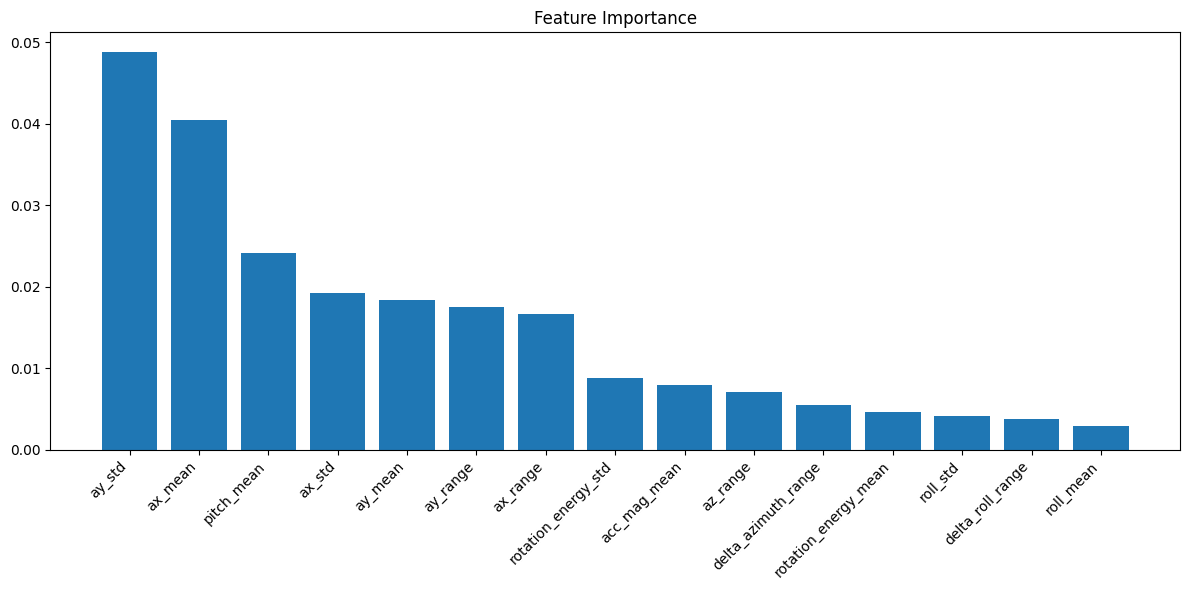

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from scipy import stats


FILE_PATH = '/content/drive/MyDrive/final_rash_data.csv'
WINDOW_SIZE = 50
STEP_SIZE = 25


def engineer_features(df):
    print("--- Step 1: Feature Engineering ---")


    df = df.sort_values(['device_id', 'timestamp']).reset_index(drop=True)

    # Magnitude (Total Force)
    df['acc_mag'] = np.sqrt(df['ax']**2 + df['ay']**2 + df['az']**2)
    # Jerk (Change in Force - "Shakiness")
    df['jerk_mag'] = df.groupby('device_id')['acc_mag'].diff().fillna(0)

    # Pitch Delta (Nose diving / Hard Braking)
    df['delta_pitch'] = df.groupby('device_id')['pitch'].diff().fillna(0)

    # Roll Delta (Leaning / Hard Cornering)
    df['delta_roll'] = df.groupby('device_id')['roll'].diff().fillna(0)

    # Azimuth Delta (Turning Rate / "Virtual Gyro")
    df['delta_azimuth'] = df.groupby('device_id')['azimuth'].diff().fillna(0)

    df['delta_azimuth'] = df['delta_azimuth'].apply(
        lambda x: x - 360 if x > 180 else (x + 360 if x < -180 else x)
    )


    df['rotation_energy'] = np.sqrt(df['delta_pitch']**2 + df['delta_roll']**2 + df['delta_azimuth']**2)

    print("Features Created: ax, ay, az, acc_mag, jerk_mag, pitch, roll, delta_pitch, delta_roll, delta_azimuth, rotation_energy")
    return df


def create_statistical_dataset(df):
    print("\n--- Step 2: Feature Selection ---")

    X_stats = []
    y_labels = []

    features_to_analyze = [
        'ax', 'ay', 'az',
        'acc_mag', 'jerk_mag',
        'pitch', 'roll',
        'delta_pitch', 'delta_roll', 'delta_azimuth',
        'rotation_energy'
    ]

    feature_names_out = []

    for device_id, group in df.groupby('device_id'):
        values = group[features_to_analyze].values
        labels = group['is_rash'].values

        for i in range(0, len(group) - WINDOW_SIZE, STEP_SIZE):
            window_data = values[i : i + WINDOW_SIZE]
            window_y = labels[i : i + WINDOW_SIZE]

            label = 1 if np.mean(window_y) > 0.5 else 0

            row = []
            current_names = []

            for f_idx, f_name in enumerate(features_to_analyze):
                f_data = window_data[:, f_idx]

                row.append(np.mean(f_data))
                if i == 0: current_names.append(f"{f_name}_mean")

                row.append(np.std(f_data))
                if i == 0: current_names.append(f"{f_name}_std")

                row.append(np.ptp(f_data))
                if i == 0: current_names.append(f"{f_name}_range")

            X_stats.append(row)
            y_labels.append(label)
            if i == 0: feature_names_out = current_names

    return np.array(X_stats), np.array(y_labels), feature_names_out


try:
    df_raw = pd.read_csv(FILE_PATH)
except FileNotFoundError:
    print(f"Error: {FILE_PATH} not found. Please upload it.")
    exit()


df_engineered = engineer_features(df_raw)

X, y, feat_names = create_statistical_dataset(df_engineered)
print(f"\nDataset Shape: {X.shape}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print("Running Permutation Importance...")
result = permutation_importance(rf, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)
sorted_idx = result.importances_mean.argsort()[::-1]

print("\n" + "="*40)
print("TOP FEATURES:")
print("="*40)

top_features = []
for i in range(15):
    idx = sorted_idx[i]
    score = result.importances_mean[idx]
    name = feat_names[idx]
    top_features.append(name)
    print(f"{i+1:2d}. {name:<25} (Score: {score:.4f})")

plt.figure(figsize=(12, 6))

plt.bar(range(15), result.importances_mean[sorted_idx[:15]], align='center')
plt.xticks(range(15), [feat_names[i] for i in sorted_idx[:15]], rotation=45, ha='right')
plt.title("Feature Importance")
plt.tight_layout()
plt.savefig('feature_selection.png')
plt.show()


##### Old model - less accuracy - not important

In [ ]:
# # Not important, not in the main code but still run it


# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, classification_report

# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization, Flatten
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# # --- 1. DATA PREPARATION (RE-RUNNING FEATURE ENGINEERING) ---
# print("--- Step 1: Preparing Data for All Models ---")

# # Load and Engineering (Same as before)
# df = pd.read_csv('/content/drive/MyDrive/final_rash_data.csv') # Ensure correct path
# df = df.sort_values(['device_id', 'timestamp']).reset_index(drop=True)

# # 1. Physics Features
# df['acc_mag'] = np.sqrt(df['ax']**2 + df['ay']**2 + df['az']**2)
# df['jerk_mag'] = df.groupby('device_id')['acc_mag'].diff().fillna(0)
# df['delta_pitch'] = df.groupby('device_id')['pitch'].diff().fillna(0)
# df['delta_roll'] = df.groupby('device_id')['roll'].diff().fillna(0)
# df['delta_azimuth'] = df.groupby('device_id')['azimuth'].diff().fillna(0)
# df['delta_azimuth'] = df['delta_azimuth'].apply(lambda x: x - 360 if x > 180 else (x + 360 if x < -180 else x))
# df['rotation_energy'] = np.sqrt(df['delta_pitch']**2 + df['delta_roll']**2 + df['delta_azimuth']**2)

# # 2. Define Feature Sets
# # RAW COLS (For LSTM/CNN - Temporal Models)
# SEQ_COLS = ['ax', 'ay', 'az', 'acc_mag', 'jerk_mag', 'pitch', 'roll', 'delta_azimuth', 'rotation_energy']

# # 3. GENERATE TWO DATASETS (Stats vs Sequences)
# X_seq = []   # For LSTM/CNN
# X_stats = [] # For DT/RF/MLP
# y = []

# for device_id, group in df.groupby('device_id'):
#     # Raw values for sequence
#     seq_values = group[SEQ_COLS].values
#     # Labels
#     labels = group['is_rash'].values

#     for i in range(0, len(group) - 50, 25): # Window=50, Step=25
#         # 1. Sequence Data
#         window_seq = seq_values[i : i + 50]

#         # 2. Statistical Data (Flattening the window into summary stats)
#         # We calculate Mean, Std, Range for every column in SEQ_COLS
#         window_stats = []
#         for col_idx in range(window_seq.shape[1]):
#             col_data = window_seq[:, col_idx]
#             window_stats.extend([np.mean(col_data), np.std(col_data), np.ptp(col_data)])

#         # 3. Label
#         label = 1 if np.mean(labels[i : i + 50]) > 0.5 else 0

#         X_seq.append(window_seq)
#         X_stats.append(window_stats)
#         y.append(label)

# X_seq = np.array(X_seq)
# X_stats = np.array(X_stats)
# y = np.array(y)

# print(f"Data Prepared. Windows: {len(y)}")
# print(f"Stats Shape (DT/RF): {X_stats.shape}")
# print(f"Seq Shape (LSTM/CNN): {X_seq.shape}")

# # --- 2. SPLIT & SCALE ---
# # We split INDICES so both datasets match perfectly
# indices = np.arange(len(y))
# idx_train, idx_test, y_train, y_test = train_test_split(indices, y, test_size=0.2, random_state=42, stratify=y)

# # Dataset A: Statistical (DT, RF, MLP)
# X_stats_train = X_stats[idx_train]
# X_stats_test = X_stats[idx_test]

# # Scale Stats (Crucial for MLP)
# scaler_stats = StandardScaler()
# X_stats_train_sc = scaler_stats.fit_transform(X_stats_train)
# X_stats_test_sc = scaler_stats.transform(X_stats_test)

# # Dataset B: Sequential (LSTM, CNN)
# X_seq_train = X_seq[idx_train]
# X_seq_test = X_seq[idx_test]

# # Scale Seq (Crucial for Deep Learning)
# N_train, T, F = X_seq_train.shape
# N_test, _, _ = X_seq_test.shape
# scaler_seq = StandardScaler()
# X_seq_train_sc = scaler_seq.fit_transform(X_seq_train.reshape(-1, F)).reshape(N_train, T, F)
# X_seq_test_sc = scaler_seq.transform(X_seq_test.reshape(-1, F)).reshape(N_test, T, F)

# # --- 3. TRAIN MODELS ---
# results = {}

# # 1. Decision Tree
# print("\n[1/5] Training Decision Tree...")
# dt = DecisionTreeClassifier(max_depth=10, random_state=42)
# dt.fit(X_stats_train, y_train)
# results['DT'] = dt.predict_proba(X_stats_test)[:, 1]

# # 2. Random Forest
# print("[2/5] Training Random Forest...")
# rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)
# rf.fit(X_stats_train, y_train)
# results['RF'] = rf.predict_proba(X_stats_test)[:, 1]

# # 3. MLP (Neural Net)
# print("[3/5] Training MLP...")
# mlp = Sequential([
#     Input(shape=(X_stats_train.shape[1],)),
#     Dense(64, activation='relu'), Dropout(0.3),
#     Dense(32, activation='relu'),
#     Dense(1, activation='sigmoid')
# ])
# mlp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# mlp.fit(X_stats_train_sc, y_train, epochs=30, batch_size=32, verbose=0)
# results['MLP'] = mlp.predict(X_stats_test_sc).flatten()

# # 4. LSTM
# print("[4/5] Training LSTM...")
# lstm = Sequential([
#     Input(shape=(T, F)),
#     LSTM(64, return_sequences=False), Dropout(0.3),
#     Dense(32, activation='relu'),
#     Dense(1, activation='sigmoid')
# ])
# lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# lstm.fit(X_seq_train_sc, y_train, epochs=30, batch_size=32, verbose=0)
# results['LSTM'] = lstm.predict(X_seq_test_sc).flatten()

# # 5. CNN-LSTM (The Super Model)
# print("[5/5] Training CNN-LSTM...")
# cnn = Sequential([
#     Input(shape=(T, F)),
#     Conv1D(64, 3, activation='relu', padding='same'),
#     BatchNormalization(), MaxPooling1D(2),
#     LSTM(64, return_sequences=False), Dropout(0.3),
#     Dense(32, activation='relu'),
#     Dense(1, activation='sigmoid')
# ])
# cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# cnn.fit(X_seq_train_sc, y_train, epochs=40, batch_size=32, verbose=0)
# results['CNN-LSTM'] = cnn.predict(X_seq_test_sc).flatten()

# # --- 4. COMPARISON & VISUALIZATION ---
# print("\n" + "="*50)
# print(f"{'MODEL':<15} | {'ACCURACY':<10} | {'AUC SCORE':<10}")
# print("="*50)

# plt.figure(figsize=(10, 6))

# for name, preds in results.items():
#     # Convert probs to binary class for Accuracy
#     binary_preds = (preds > 0.5).astype(int)
#     acc = accuracy_score(y_test, binary_preds)
#     auc = roc_auc_score(y_test, preds)

#     print(f"{name:<15} | {acc:.4f}     | {auc:.4f}")

#     # Plot ROC
#     fpr, tpr, _ = roc_curve(y_test, preds)
#     plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

# plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
# plt.title('Final Model Comparison (With Orientation Features)')
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.savefig('final_comparison.png')
# plt.show()

###### Better approach but only for CNN-LSTM

In [ ]:
### Better approach for better performance - Only CNN_LSTM

In [ ]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
# from xgboost import XGBClassifier

# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# # --- 1. DATA PREP (Same as before) ---
# # We assume X_stats (2396, 27), X_seq (2396, 50, 9), and y (2396,) exist from previous step.
# # If variables are lost, please re-run the previous "Data Preparation" block first.

# print("--- Step 1: Splitting Data ---")
# indices = np.arange(len(y))
# idx_train, idx_test, y_train, y_test = train_test_split(indices, y, test_size=0.2, random_state=42, stratify=y)

# # Prepare Stats Data (For XGBoost)
# scaler_stats = StandardScaler()
# X_stats_train = scaler_stats.fit_transform(X_stats[idx_train])
# X_stats_test = scaler_stats.transform(X_stats[idx_test])

# # Prepare Seq Data (For Deep Learning)
# scaler_seq = StandardScaler()
# N_train, T, F = X_seq[idx_train].shape
# N_test, _, _ = X_seq[idx_test].shape

# # Scale 3D data by flattening
# X_seq_train = scaler_seq.fit_transform(X_seq[idx_train].reshape(-1, F)).reshape(N_train, T, F)
# X_seq_test = scaler_seq.transform(X_seq[idx_test].reshape(-1, F)).reshape(N_test, T, F)

# # --- 2. MODEL A: XGBOOST (The "Calculator") ---
# print("\n[1/3] Training XGBoost (Gradient Boosting)...")
# # XGBoost is like Random Forest on steroids. It learns from its mistakes.
# xgb = XGBClassifier(
#     n_estimators=300,        # More trees
#     learning_rate=0.05,      # Slower learning = better generalization
#     max_depth=6,             # Deeper trees
#     subsample=0.8,           # Prevent overfitting
#     colsample_bytree=0.8,
#     random_state=42,
#     n_jobs=-1
# )
# xgb.fit(X_stats_train, y_train)
# xgb_preds = xgb.predict_proba(X_stats_test)[:, 1]
# print(f"XGBoost AUC: {roc_auc_score(y_test, xgb_preds):.4f}")

# # --- 3. MODEL B: DEEP ENSEMBLE (The "Brain") ---
# print("\n[2/3] Training CNN-LSTM Ensemble...")

# def build_cnn_lstm():
#     model = Sequential([
#         Input(shape=(T, F)),
#         Conv1D(64, 3, activation='relu', padding='same'),
#         BatchNormalization(),
#         MaxPooling1D(2),
#         LSTM(64, return_sequences=True), # Added return_sequences=True for depth
#         Dropout(0.3),
#         LSTM(32, return_sequences=False),
#         Dropout(0.3),
#         Dense(32, activation='relu'),
#         Dense(1, activation='sigmoid')
#     ])
#     model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
#     return model

# # We train 3 separate models and average them
# n_models = 3
# deep_preds_total = np.zeros(len(y_test))

# for i in range(n_models):
#     print(f"  Training Sub-Model {i+1}/{n_models}...")
#     model = build_cnn_lstm()

#     # Callbacks for maximum performance
#     es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)
#     rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=0)

#     # Train
#     model.fit(
#         X_seq_train, y_train,
#         validation_split=0.1, # Use part of train as internal validation
#         epochs=40,
#         batch_size=32,
#         callbacks=[es, rlr],
#         verbose=0
#     )

#     # Predict
#     deep_preds_total += model.predict(X_seq_test, verbose=0).flatten()

# # Average the predictions
# deep_preds_avg = deep_preds_total / n_models
# print(f"Deep Ensemble AUC: {roc_auc_score(y_test, deep_preds_avg):.4f}")

# # --- 4. HYBRID BLENDING (The "Super Model") ---
# print("\n[3/3] Blending Models...")

# # Weighted Average: We trust the Deep Learning slightly more (0.6)
# # You can tweak these weights based on which AUC was higher above
# final_preds_prob = (0.4 * xgb_preds) + (0.6 * deep_preds_avg)
# final_preds_bin = (final_preds_prob > 0.5).astype(int)

# # --- 5. FINAL RESULTS ---
# print("\n" + "="*50)
# print("ULTIMATE ENSEMBLE RESULTS")
# print("="*50)
# print(classification_report(y_test, final_preds_bin))
# final_auc = roc_auc_score(y_test, final_preds_prob)
# print(f"FINAL AUC SCORE: {final_auc:.4f}")
# print("="*50)

# # Plot Confusion Matrix
# cm = confusion_matrix(y_test, final_preds_bin)
# plt.figure(figsize=(6, 5))m
# sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
# plt.title(f'Ensemble Confusion Matrix (AUC={final_auc:.3f})')
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.savefig('ensemble_matrix.png')
# plt.show()

# # --- 6. SAVE EVERYTHING (IF SATISFIED) ---
# # To save an ensemble, we must save ALL components
# # model.save('cnn_lstm_1.h5') ... (We will do this in the next step if you like the results)

##### Better model

In [ ]:
### Better approach for better performance for all the models

--- Step 1: Loading & Splitting Data ---

[1/5] Training Optimized Tree (XGBoost)...
[2/5] Training Optimized Random Forest...
[3/5] Training Optimized MLP (ResNet-style)...


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  
[4/5] Training Optimized LSTM (Bi-Directional)...
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
[5/5] Training Optimized CNN-LSTM (Ensemble)...

MODEL                     | ACCURACY   | AUC SCORE 
CNN-LSTM: Ensemble CNN-LSTM | 0.8938     | 0.9551
LSTM: Bi-LSTM             | 0.8458     | 0.9352
Random Forest: Tuned RF   | 0.8458     | 0.9221
Decision Tree: XGBoost (DT Upgrade) | 0.8292     | 0.9171
MLP: ResNet MLP           | 0.8438     | 0.9087


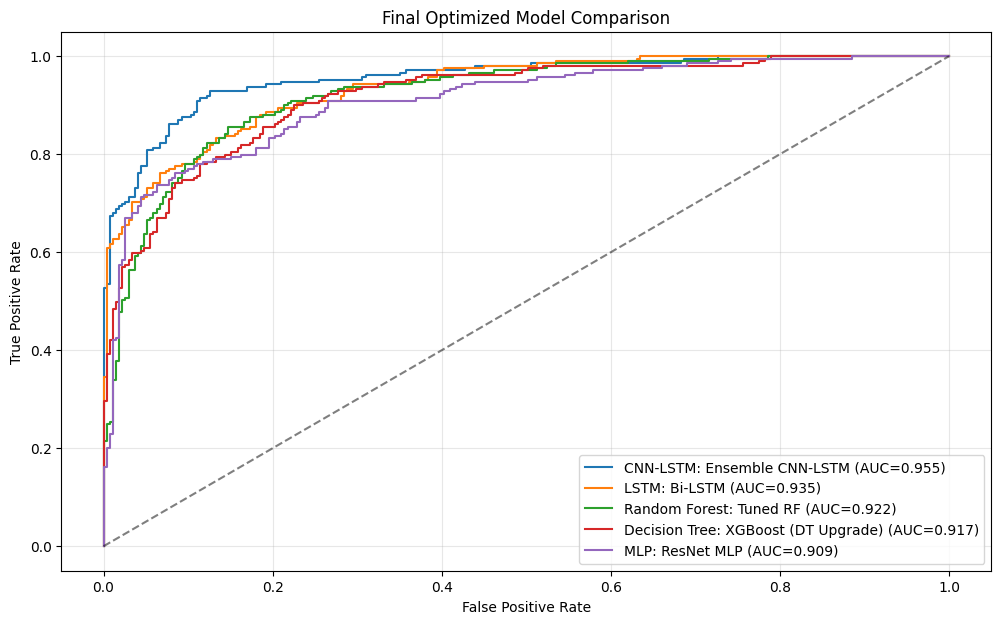

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, classification_report
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization, Flatten, Add, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("--- Step 1: Loading & Splitting Data ---")

indices = np.arange(len(y))
idx_train, idx_test, y_train, y_test = train_test_split(indices, y, test_size=0.2, random_state=42, stratify=y)


scaler_stats = StandardScaler()
X_stats_train = scaler_stats.fit_transform(X_stats[idx_train])
X_stats_test = scaler_stats.transform(X_stats[idx_test])


scaler_seq = StandardScaler()
N_train, T, F = X_seq[idx_train].shape
N_test, _, _ = X_seq[idx_test].shape
X_seq_train = scaler_seq.fit_transform(X_seq[idx_train].reshape(-1, F)).reshape(N_train, T, F)
X_seq_test = scaler_seq.transform(X_seq[idx_test].reshape(-1, F)).reshape(N_test, T, F)

results = {}


# [1] DECISION TREE -> XGBOOST (The Ultimate Tree)
print("\n[1/5] Training Optimized Tree (XGBoost)...")
xgb = XGBClassifier(
    n_estimators=500, learning_rate=0.01, max_depth=6,
    subsample=0.7, colsample_bytree=0.7, random_state=42, n_jobs=-1
)
xgb.fit(X_stats_train, y_train)
results['Decision Tree: XGBoost (DT Upgrade)'] = xgb.predict_proba(X_stats_test)[:, 1]

# [2] RANDOM FOREST -> TUNED RF
print("[2/5] Training Optimized Random Forest...")
rf = RandomForestClassifier(
    n_estimators=300, max_depth=20, min_samples_split=5,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_stats_train, y_train)
results['Random Forest: Tuned RF'] = rf.predict_proba(X_stats_test)[:, 1]

# [3] MLP -> DEEP RESNET MLP
print("[3/5] Training Optimized MLP (ResNet-style)...")
def build_resnet_mlp():
    inputs = Input(shape=(X_stats_train.shape[1],))
    x = Dense(64, activation='relu')(inputs)
    x = BatchNormalization()(x)

    shortcut = x
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Add()([x, shortcut])

    x = Dense(32, activation='relu')(x)
    outputs = Dense(1, activation='sigmoid')(x)
    return Model(inputs, outputs)

mlp = build_resnet_mlp()
mlp.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
mlp.fit(X_stats_train, y_train, epochs=50, batch_size=32, verbose=0, callbacks=[EarlyStopping(patience=5)])
results['MLP: ResNet MLP'] = mlp.predict(X_stats_test).flatten()

# [4] LSTM -> BI-DIRECTIONAL LSTM
print("[4/5] Training Optimized LSTM (Bi-Directional)...")
# Bi-LSTM reads sequence Forwards AND Backwards
lstm = Sequential([
    Input(shape=(T, F)),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
lstm.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
lstm.fit(X_seq_train, y_train, epochs=40, batch_size=32, verbose=0, callbacks=[EarlyStopping(patience=8)])
results['LSTM: Bi-LSTM'] = lstm.predict(X_seq_test).flatten()

# [5] CNN-LSTM -> DEEP ENSEMBLE (3 Models Averaged)
print("[5/5] Training Optimized CNN-LSTM (Ensemble)...")
cnn_preds = np.zeros(len(y_test))
n_ensemble = 3

for i in range(n_ensemble):
    model = Sequential([
        Input(shape=(T, F)),
        Conv1D(64, 3, activation='relu', padding='same'),
        BatchNormalization(), MaxPooling1D(2),
        LSTM(64, return_sequences=True), Dropout(0.3),
        LSTM(32), Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
    model.fit(X_seq_train, y_train, epochs=40, batch_size=32, verbose=0, callbacks=[EarlyStopping(patience=8)])
    cnn_preds += model.predict(X_seq_test, verbose=0).flatten()

results['CNN-LSTM: Ensemble CNN-LSTM'] = cnn_preds / n_ensemble


print("\n" + "="*60)
print(f"{'MODEL':<25} | {'ACCURACY':<10} | {'AUC SCORE':<10}")
print("="*60)

plt.figure(figsize=(12, 7))


sorted_results = sorted(results.items(), key=lambda x: roc_auc_score(y_test, x[1]), reverse=True)

for name, preds in sorted_results:
    acc = accuracy_score(y_test, (preds > 0.5).astype(int))
    auc = roc_auc_score(y_test, preds)
    print(f"{name:<25} | {acc:.4f}     | {auc:.4f}")

    fpr, tpr, _ = roc_curve(y_test, preds)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title('Final Optimized Model Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('model_comparison_auc.png')
plt.show()

In [ ]:
#### Precision reacall curve

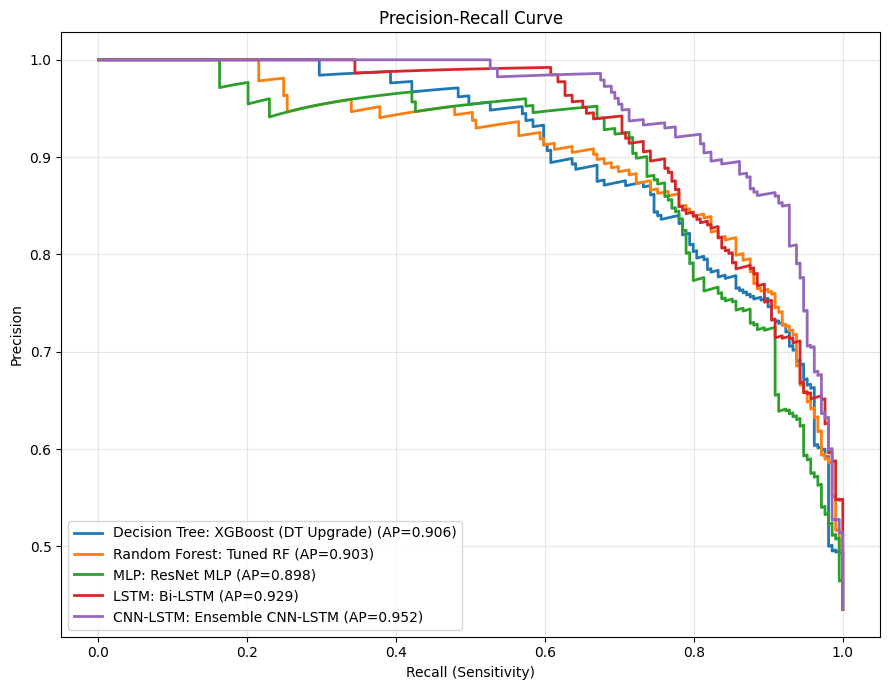

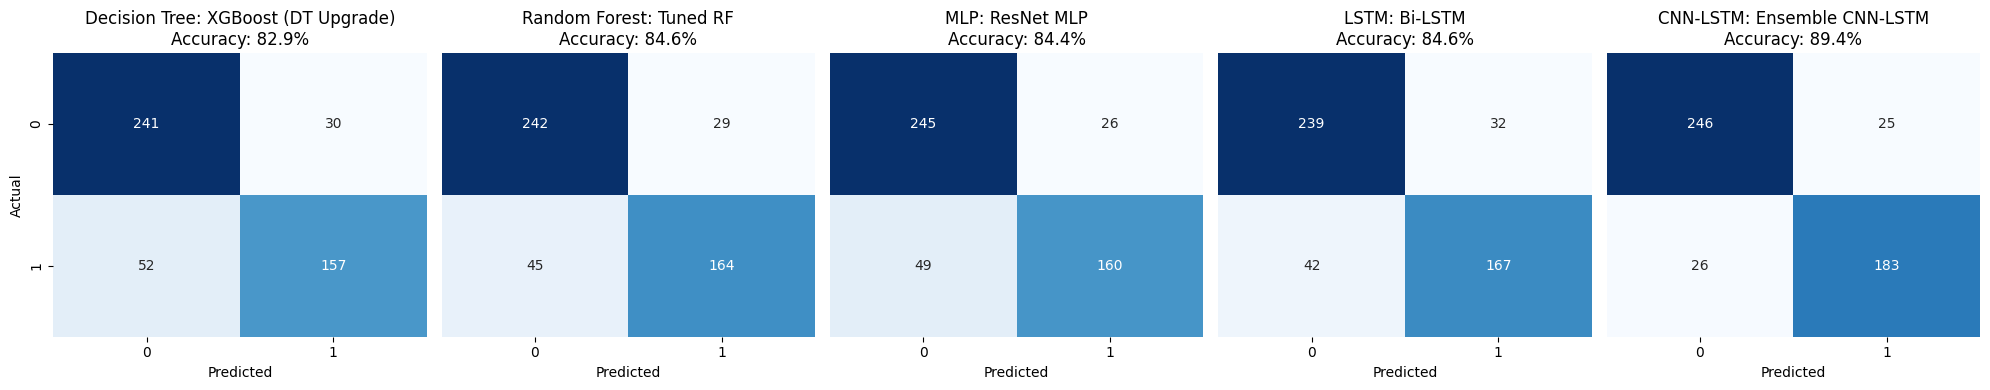

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, average_precision_score, confusion_matrix, accuracy_score


plt.figure(figsize=(9, 7))

for name, preds in results.items():
    precision, recall, _ = precision_recall_curve(y_test, preds)
    ap = average_precision_score(y_test, preds)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})", linewidth=2)

plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('precision_recall_curve.png')
plt.show()


fig_cm, axes_cm = plt.subplots(1, len(results), figsize=(20, 4))

for i, (name, preds) in enumerate(results.items()):

    binary_preds = (preds > 0.5).astype(int)
    cm = confusion_matrix(y_test, binary_preds)


    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[i], cbar=False)
    axes_cm[i].set_title(f"{name}\nAccuracy: {accuracy_score(y_test, binary_preds):.1%}")
    axes_cm[i].set_xlabel("Predicted")
    if i == 0:
        axes_cm[i].set_ylabel("Actual")
    else:
        axes_cm[i].set_yticks([])

plt.tight_layout()
plt.savefig('confusion_matrix_comparison.png')
plt.show()

##### Model Export

In [ ]:
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler

MODEL_PATH = "rash_driving_model.h5"
SCALER_PATH = "server_scaler.pkl"

print("--- Training Model on 100% Data ---")


N, T, F = X_seq.shape
scaler_final = StandardScaler()
X_flat = X_seq.reshape(-1, F)
X_full_scaled = scaler_final.fit_transform(X_flat).reshape(N, T, F)

print(f"Final Data Shape: {X_full_scaled.shape}")

model = Sequential([
    Input(shape=(T, F)),

    Conv1D(64, 3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(2),

    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32, return_sequences=False),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

model.fit(
    X_full_scaled, y,
    epochs=50,
    batch_size=32,
    verbose=1
)
model.save(MODEL_PATH)
joblib.dump(scaler_final, SCALER_PATH)

print("Saved Model and Scaler")

--- Training Model on 100% Data ---
Final Data Shape: (2396, 50, 9)
Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.6229 - loss: 0.6392
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.8170 - loss: 0.4243
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.8779 - loss: 0.3069
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.8873 - loss: 0.2872
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9037 - loss: 0.2355
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9006 - loss: 0.2291
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9082 - loss: 0.2233
Epoch 8/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9249 - loss: 0.1784
Epoch 9/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.9249 - loss: 0.1854
Epoch 10/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9472 - loss: 0.1351
Epoch 11/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9248 - loss: 0.

Saved Model and Scaler
